# Week 3 Day 4 — Comparing Classification Models

## Decision Tree, Random Forest, SVM, and k-Nearest Neighbors

This notebook compares four supervised classification algorithms:

1. Decision Tree
2. Random Forest
3. Support Vector Machine
4. k-Nearest Neighbors

All models use the same dataset and the same train/test split. Their
performance is compared primarily using the F1-score.

Random Forest feature importances are also examined and interpreted.

## Learning Objectives

By the end of this notebook, I will be able to:

- train Decision Tree, Random Forest, SVM, and k-NN classifiers;
- explain the basic decision-making approach of each algorithm;
- use one reproducible train/test split for fair model comparison;
- scale features correctly for SVM and k-NN without data leakage;
- evaluate all models using the same classification metrics;
- compare model performance in one results table;
- extract and interpret Random Forest feature importances;
- identify and justify the best-performing classifier.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.inspection import DecisionBoundaryDisplay

# Make displayed tables easier to read.
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Understanding the Four Models

### Decision Tree

A Decision Tree predicts a class by asking a sequence of rule-based questions
about the features. It is easy to interpret, but a deep tree may memorize the
training data and overfit.

### Random Forest

A Random Forest trains many Decision Trees using different samples and feature
subsets. The trees vote on the final prediction. This usually improves
generalization and reduces the overfitting of a single Decision Tree.

### Support Vector Machine

An SVM searches for a decision boundary that separates the classes with the
largest possible margin. With a nonlinear kernel, such as the RBF kernel, it
can learn curved decision boundaries.

### k-Nearest Neighbors

k-NN classifies a new observation using the classes of its nearest training
observations. It is simple and intuitive, but it is sensitive to feature
scales and can become slow on large datasets.

In [2]:
dataset = load_breast_cancer()

X = pd.DataFrame(
    dataset.data,
    columns=dataset.feature_names
)

y = pd.Series(
    dataset.target,
    name="target"
)

print("Dataset loaded successfully.")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Dataset loaded successfully.
Feature matrix shape: (569, 30)
Target shape: (569,)


In [3]:
display(X.head())

print("\nTarget names:")
print(dataset.target_names)

print("\nTarget class counts:")
print(y.value_counts().sort_index())

print("\nTarget class proportions:")
print(y.value_counts(normalize=True).sort_index().round(4))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target names:
['malignant' 'benign']

Target class counts:
target
0    212
1    357
Name: count, dtype: int64

Target class proportions:
target
0    0.3726
1    0.6274
Name: proportion, dtype: float64


## Dataset Description

The feature matrix contains measurements calculated from digitized images of
breast masses.

The target is binary:

- `0` represents malignant cases;
- `1` represents benign cases.

This is a supervised classification problem because the target contains
discrete class labels rather than continuous numeric values.

In [4]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate feature rows:", X.duplicated().sum())
print("Number of features:", X.shape[1])
print("Number of observations:", X.shape[0])

Missing values: 0
Duplicate feature rows: 0
Number of features: 30
Number of observations: 569


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training and test data created successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Training and test data created successfully.
X_train shape: (455, 30)
X_test shape:  (114, 30)
y_train shape: (455,)
y_test shape:  (114,)


In [6]:
class_distribution = pd.DataFrame({
    "Training Count": y_train.value_counts().sort_index(),
    "Testing Count": y_test.value_counts().sort_index(),
    "Training Proportion": y_train.value_counts(
        normalize=True
    ).sort_index().round(4),
    "Testing Proportion": y_test.value_counts(
        normalize=True
    ).sort_index().round(4)
})

class_distribution.index = [
    dataset.target_names[class_id]
    for class_id in class_distribution.index
]

display(class_distribution)

,Training Count,Testing Count,Training Proportion,Testing Proportion
malignant,170,42,0.3736,0.3684
benign,285,72,0.6264,0.6316


## Train/Test Split

I reserved 20% of the observations for testing and used the remaining 80% for
training.

I used `random_state=42` so the split can be reproduced. I also used
`stratify=y` so that the malignant and benign class proportions remain
approximately equal in the training and test sets.

All four classifiers will use this exact split. This makes their performance
comparison fair because no model receives an easier or different test set.

In [7]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]),

    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])
}

print("Models created:")
for model_name in models:
    print(f"- {model_name}")

Models created:
- Decision Tree
- Random Forest
- SVM
- k-NN


## Model Configuration

The Decision Tree uses `max_depth=5` to reduce the risk of creating an
overly complex tree that memorizes the training data.

The Random Forest uses 100 Decision Trees. Combining many trees generally
produces more stable predictions than using only one tree.

The SVM uses an RBF kernel so that it can learn nonlinear class boundaries.

The k-NN classifier uses five neighboring observations.

SVM and k-NN are wrapped in pipelines with `StandardScaler`. Scaling is
important for these models because their predictions depend on distances or
margins. Decision Trees and Random Forests do not require the same scaling.

In [8]:
results = []
predictions_by_model = {}
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    trained_models[model_name] = model
    predictions_by_model[model_name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

# Sort from highest to lowest F1-score.
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.9825,0.9861,0.9861,0.9861
1,Random Forest,0.9561,0.9589,0.9722,0.9655
2,k-NN,0.9561,0.9589,0.9722,0.9655
3,Decision Tree,0.9211,0.9565,0.9167,0.9362


In [9]:
best_model_name = results_df.loc[0, "Model"]
best_f1_score = results_df.loc[0, "F1-Score"]
best_accuracy = results_df.loc[0, "Accuracy"]
best_precision = results_df.loc[0, "Precision"]
best_recall = results_df.loc[0, "Recall"]

print(f"Best model by F1-score: {best_model_name}")
print(f"F1-score: {best_f1_score:.4f}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")

Best model by F1-score: SVM
F1-score: 0.9861
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861


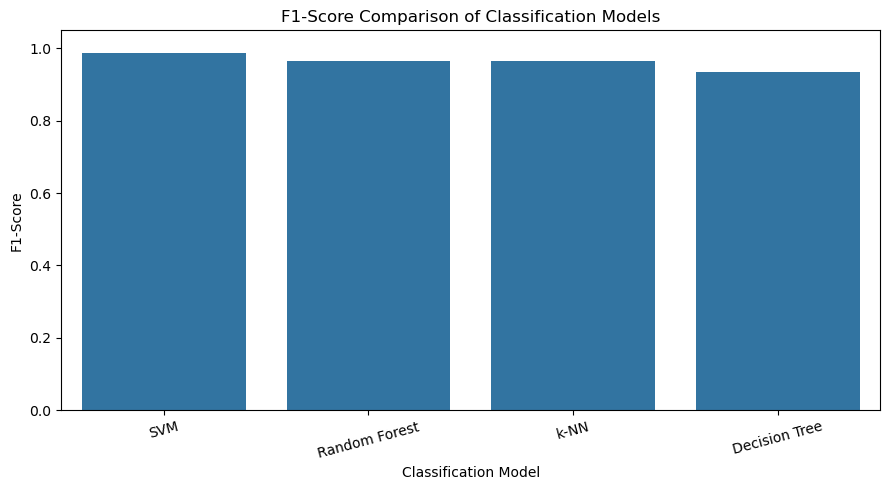

In [10]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1-Score"
)

plt.ylim(0, 1.05)
plt.xlabel("Classification Model")
plt.ylabel("F1-Score")
plt.title("F1-Score Comparison of Classification Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

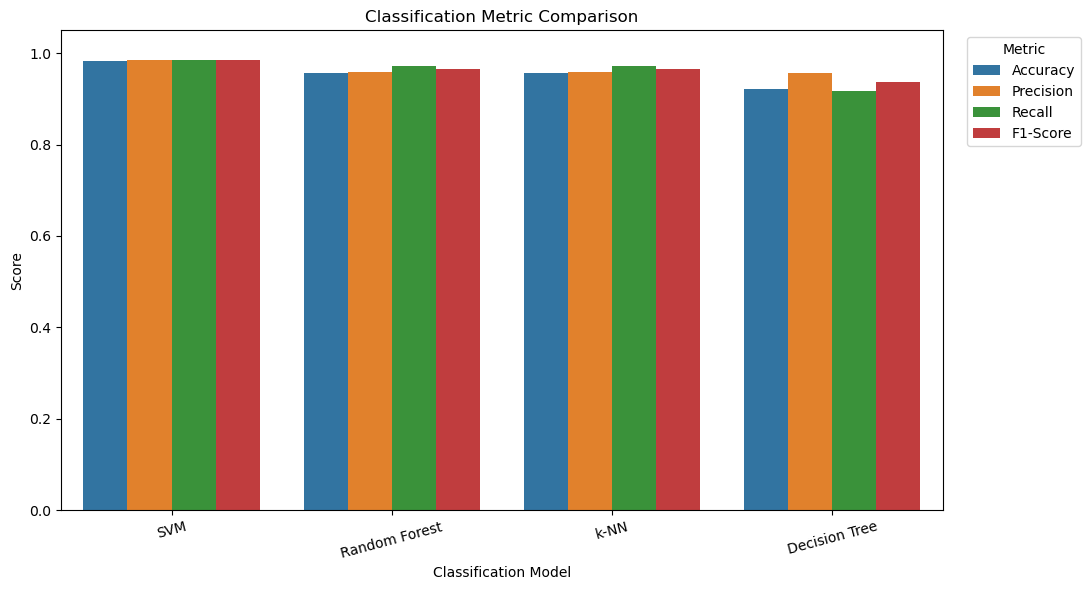

In [11]:
results_long = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1.05)
plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.title("Classification Metric Comparison")
plt.xticks(rotation=15)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Initial Model Comparison

All four classifiers were trained on the same training observations and
evaluated on the same unseen test observations.

The F1-score was used as the main comparison metric because it balances
precision and recall. Accuracy, precision, and recall were also reported to
provide a more complete evaluation.

A model should not be selected using accuracy alone. The final decision must
consider the main metric, the problem context, generalization, interpretability,
and computational cost.

In [12]:
for model_name, y_pred in predictions_by_model.items():
    print("=" * 70)
    print(f"{model_name} Classification Report")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=dataset.target_names,
            zero_division=0
        )
    )

Decision Tree Classification Report
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114

Random Forest Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

SVM Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0

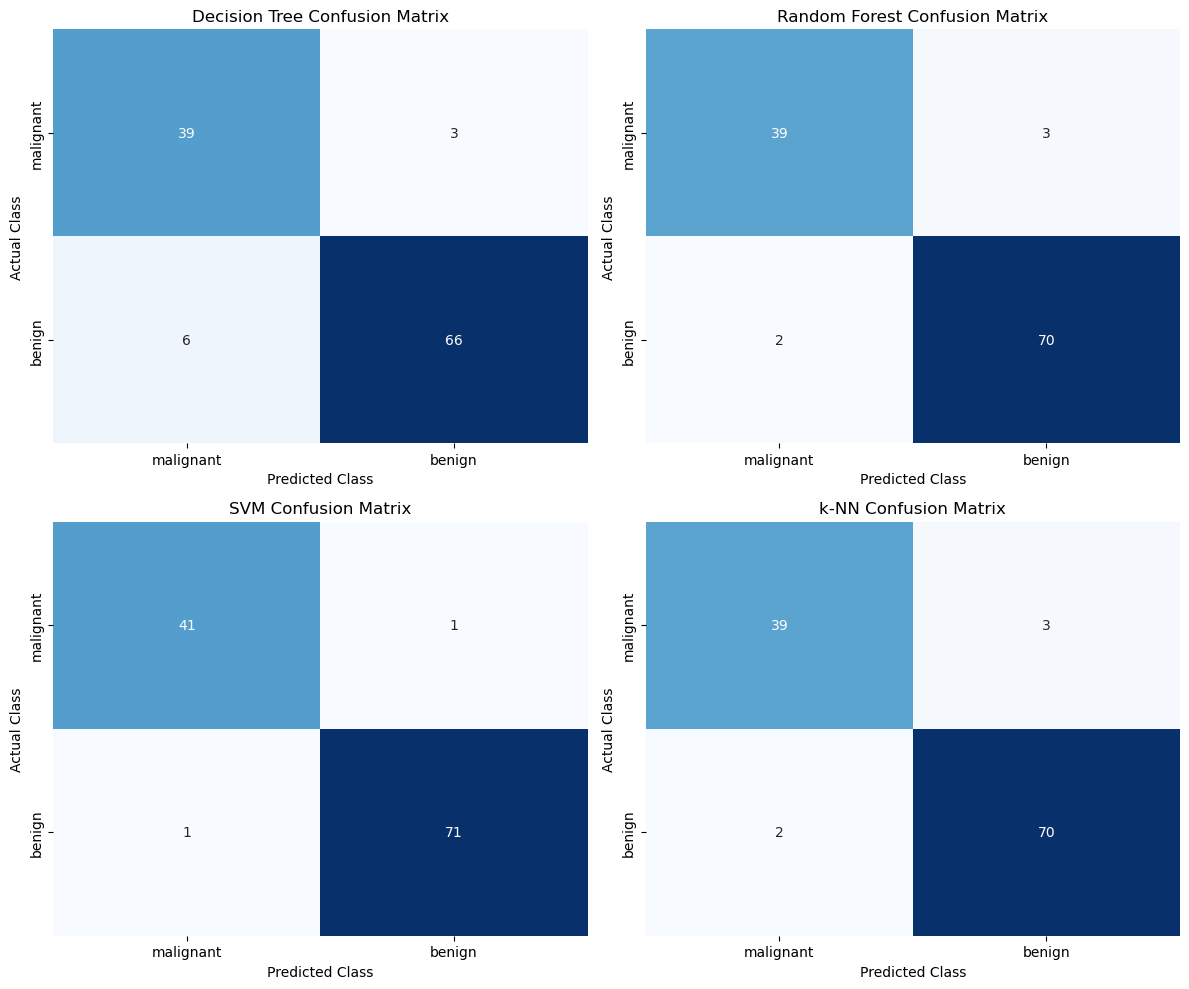

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for axis, (model_name, y_pred) in zip(
    axes,
    predictions_by_model.items()
):
    matrix = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=dataset.target_names,
        yticklabels=dataset.target_names,
        ax=axis
    )

    axis.set_title(f"{model_name} Confusion Matrix")
    axis.set_xlabel("Predicted Class")
    axis.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

## Confusion-Matrix Interpretation

Each confusion matrix shows how the classifier's predictions compare with the
actual labels.

Correct predictions appear on the main diagonal. Incorrect predictions appear
outside the diagonal.

In a medical classification context, errors involving malignant observations
deserve particular attention. A malignant case incorrectly predicted as benign
could be more harmful than a benign case incorrectly predicted as malignant.

Therefore, model selection should consider class-specific recall in addition to
the overall F1-score.

In [14]:
decision_tree = trained_models["Decision Tree"]

decision_tree_train_accuracy = decision_tree.score(
    X_train,
    y_train
)

decision_tree_test_accuracy = decision_tree.score(
    X_test,
    y_test
)

print(
    f"Decision Tree training accuracy: "
    f"{decision_tree_train_accuracy:.4f}"
)

print(
    f"Decision Tree testing accuracy: "
    f"{decision_tree_test_accuracy:.4f}"
)

print(
    f"Train-test difference: "
    f"{decision_tree_train_accuracy - decision_tree_test_accuracy:.4f}"
)

Decision Tree training accuracy: 0.9934
Decision Tree testing accuracy: 0.9211
Train-test difference: 0.0724


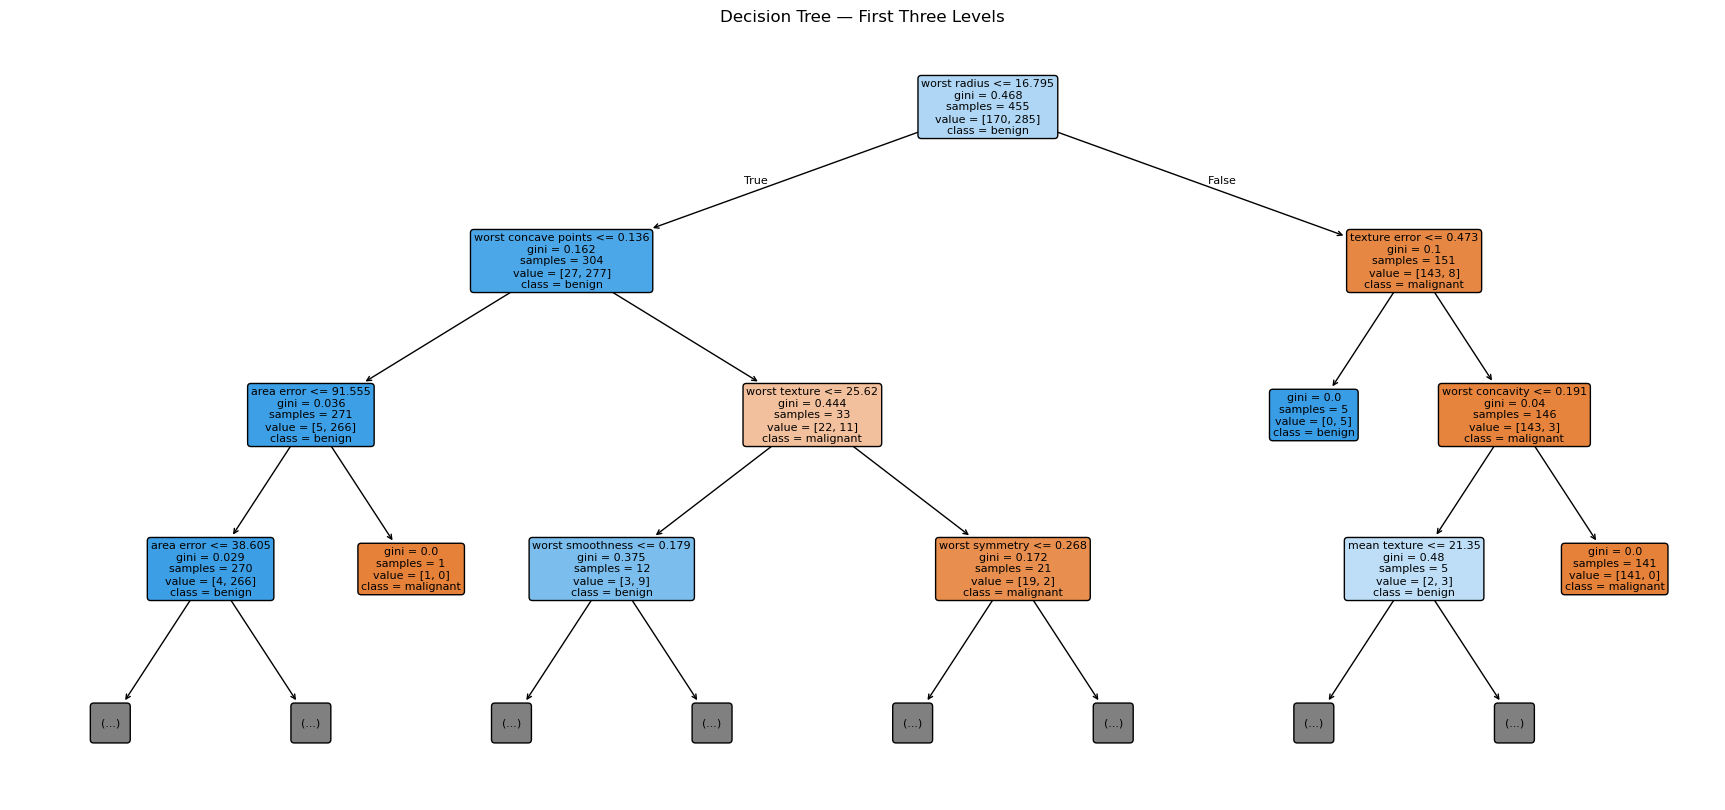

In [15]:
plt.figure(figsize=(22, 10))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree — First Three Levels")
plt.show()

## Decision Tree Interpretation

The tree uses a sequence of feature thresholds to divide observations into
different classes.

Its main advantage is interpretability because the learned decisions can be
displayed as explicit rules.

However, a Decision Tree can overfit when it is allowed to grow without
restriction. I used `max_depth=5` to control its complexity and improve its
ability to generalize to unseen observations.

In [16]:
random_forest = trained_models["Random Forest"]

feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importances = feature_importances.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 10 Random Forest feature importances:")
display(feature_importances.head(10))

Top 10 Random Forest feature importances:


,Feature,Importance
0,worst area,0.140016
1,worst concave points,0.129530
2,worst radius,0.097696
3,mean concave points,0.090885
4,worst perimeter,0.072226
5,mean perimeter,0.069574
6,mean radius,0.068676
7,mean concavity,0.057638
8,mean area,0.049172
9,worst concavity,0.034340


In [17]:
importance_total = feature_importances["Importance"].sum()

print(
    f"Total feature importance: "
    f"{importance_total:.4f}"
)

Total feature importance: 1.0000


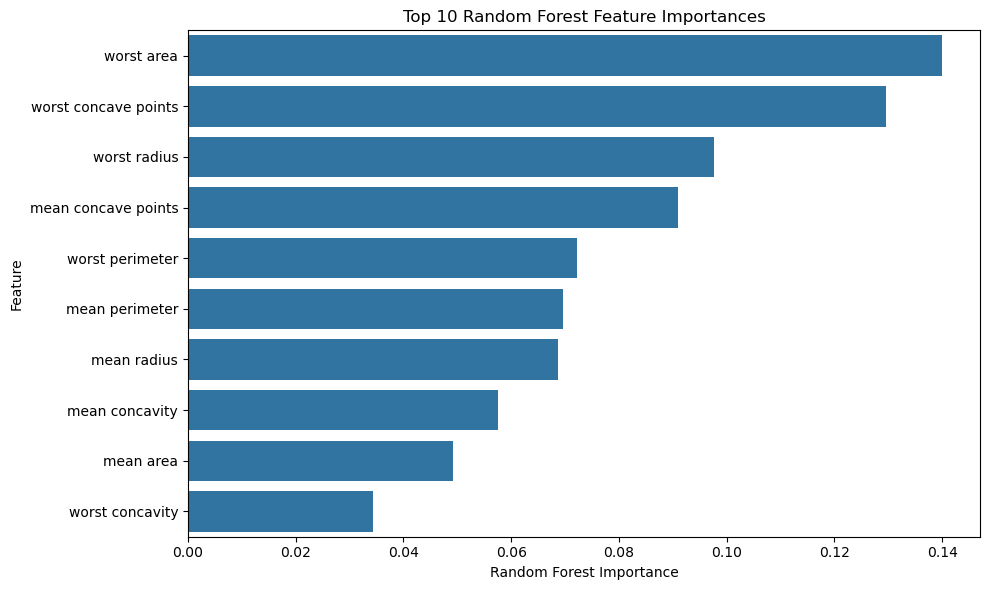

In [18]:
top_features = feature_importances.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [19]:
top_three_features = feature_importances.head(3)

print("The three most important Random Forest features are:")

for rank, row in top_three_features.iterrows():
    print(
        f"{rank + 1}. {row['Feature']} "
        f"— importance: {row['Importance']:.4f}"
    )

The three most important Random Forest features are:
1. worst area — importance: 0.1400
2. worst concave points — importance: 0.1295
3. worst radius — importance: 0.0977


## Random Forest Feature-Importance Interpretation

The Random Forest's three most influential features were:

1. **[First feature]**
2. **[Second feature]**
3. **[Third feature]**

These features received the largest importance values, which means they
contributed most strongly to the model's decision-making across its collection
of trees.

Feature importance does not prove that a feature causes the target outcome.
It only indicates that the trained Random Forest relied heavily on that
feature when making predictions.

Highly correlated features may also share or divide their importance, so the
ranking should be interpreted as a model-specific indicator rather than a
causal conclusion.

In [20]:
generalization_results = []

for model_name, model in trained_models.items():
    training_accuracy = model.score(X_train, y_train)
    testing_accuracy = model.score(X_test, y_test)

    generalization_results.append({
        "Model": model_name,
        "Training Accuracy": training_accuracy,
        "Testing Accuracy": testing_accuracy,
        "Train-Test Gap": training_accuracy - testing_accuracy
    })

generalization_df = pd.DataFrame(generalization_results)

generalization_df = generalization_df.sort_values(
    by="Testing Accuracy",
    ascending=False
).reset_index(drop=True)

display(generalization_df.round(4))

,Model,Training Accuracy,Testing Accuracy,Train-Test Gap
0,SVM,0.9824,0.9825,-0.0000
1,Random Forest,1.0000,0.9561,0.0439
2,k-NN,0.9736,0.9561,0.0175
3,Decision Tree,0.9934,0.9211,0.0724


## Generalization and Overfitting

Training performance describes how accurately a model predicts observations it
has already seen. Test performance describes how well it generalizes to unseen
observations.

A very high training score combined with a substantially lower test score may
indicate overfitting.

The Decision Tree is particularly vulnerable to overfitting because it can
create highly specific decision rules. A Random Forest usually reduces this
problem by averaging predictions from many different trees.

The train-test gap is therefore considered together with the final test
F1-score when evaluating model quality.

In [21]:
best_row = results_df.iloc[0]

print("Final model-comparison result")
print("-" * 40)
print(f"Best model: {best_row['Model']}")
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1-score: {best_row['F1-Score']:.4f}")

Final model-comparison result
----------------------------------------
Best model: SVM
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-score: 0.9861


## Best-Performing Model

The best-performing model according to the test-set F1-score was
**[insert model name]**, with an F1-score of **[insert score]**.

It also achieved:

- accuracy of **[insert accuracy]**;
- precision of **[insert precision]**;
- recall of **[insert recall]**.

This model likely performed well because **[write the explanation that matches
the winning model]**.

Possible explanations include:

- **Decision Tree:** the dataset may contain clear threshold-based rules, and
  the depth restriction may have controlled overfitting.
- **Random Forest:** combining many different trees may have reduced variance
  and produced more stable predictions than one Decision Tree.
- **SVM:** scaling and the RBF kernel may have captured a strong nonlinear
  boundary between the two classes.
- **k-NN:** after scaling, observations from the same class may have formed
  compact local neighborhoods.

The result applies to this dataset and this train/test split. It does not prove
that the winning algorithm will always be superior on every classification
problem.

## Model Comparison Discussion

### Decision Tree

The Decision Tree is the easiest model to interpret because its learned rules
can be visualized. However, it may overfit and become sensitive to small
changes in the training data.

### Random Forest

The Random Forest combines predictions from many Decision Trees. It is usually
more stable and less likely to overfit than a single tree. It also provides
feature-importance values.

### Support Vector Machine

The SVM can create a powerful nonlinear decision boundary through the RBF
kernel. It requires feature scaling and may become computationally expensive
on very large datasets.

### k-Nearest Neighbors

k-NN is intuitive because it predicts using nearby training observations.
However, its results depend strongly on scaling and the selected number of
neighbors.

### Final Selection Principle

There is no classifier that is best for every dataset. A fair professional
comparison requires the same dataset, the same split, the same preprocessing
rules, and the same evaluation metric.